In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer

output_dir = Path("outputs_text_analysis")
output_dir.mkdir(exist_ok=True)

data_path = Path("data/bitcoin_tweet.parquet")
text_col = "text"

df = pd.read_parquet(data_path)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset shape: (632179, 13)
Columns: ['user_name', 'user_created', 'user_followers', 'user_friends', 'user_verified', 'date', 'text', 'hashtags', 'mentions', 'account_age_days', 'age_bucket', 'url_count', 'text_clean']


In [2]:
custom_stopwords_hd = {
    "rt", "amp", "https", "http", "www", "com",
    "username", "user", "users", "tweet", "tweets", "twitter",
    "follow", "followers", "link", "join", "tips",
    "btc", "bitcoin", "crypto", "cryptocurrency",
    "just", "like", "time", "people", "don", "good", "going", "think",
    "know", "make", "need", "new", "really", "want", "way", "day",
    "today", "thing", "things", "let", "look", "still", "much",
    "many", "say", "said", "year", "years", "week", "weeks",
    "great", "right", "best", "big", "soon", "use", "better",
    "seasonaltokens", "cryptomining", "cyclicalinvesting", "cyclicallnvesting",
    "betfurysuccess", "cashback", "rank", "play", "higher", "staking"
}

stopwords_hd = set(ENGLISH_STOP_WORDS).union(custom_stopwords_hd)

def clean_text_hd(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = [
        word for word in text.split()
        if word not in stopwords_hd and len(word) > 2
    ]

    return " ".join(tokens)

df["clean_text_hd"] = df[text_col].apply(clean_text_hd)
df_clean_hd = df[df["clean_text_hd"].str.len() > 2].copy()

print("Original rows:", len(df))
print("Rows after cleaning:", len(df_clean_hd))

df_clean_hd[[text_col, "clean_text_hd"]].head(10)

Original rows: 632179
Rows after cleaning: 627413


,text,clean_text_hd
16,@MexcResearch @MEXC_Fans @MEXC_Updates #BTC - ...,amazing impressed project hopefully event comm...
24,@iamDonaldYusuf @yuzomausman @aproko_doctor No...,fud sub wan risk buy prices imo
25,I personally ignore weekend moves and chill wi...,personally ignore weekend moves chill family
31,Move Digital Energy Through Cyber Space. #Bitc...,digital energy cyber space
51,"1/2 End of shitcoin season, lasted even longer...",end shitcoin season lasted longer expected fro...
59,More traditional market content going on the T...,traditional market content tube content youtub...
61,Less than 10hours to save #Bitcoin weekly cand...,hours save weekly candle
87,@JasonPLowery Real Question?\n\nWouldn’t this ...,real question wouldn mean nations warfare long...
89,@JoshuaBarbin1 @danheld How do you get more de...,decentralized network tens thousands nodes cou...
110,#11MINUTES #BTC #CRYPTO\nThis project is a pro...,minutes project profitable project investors i...


,word,frequency
0,buy,48810
1,eth,41161
2,market,38591
3,money,37050
4,price,32977
5,project,30532
6,ethereum,23295
7,world,20846
8,long,18557
9,future,17046


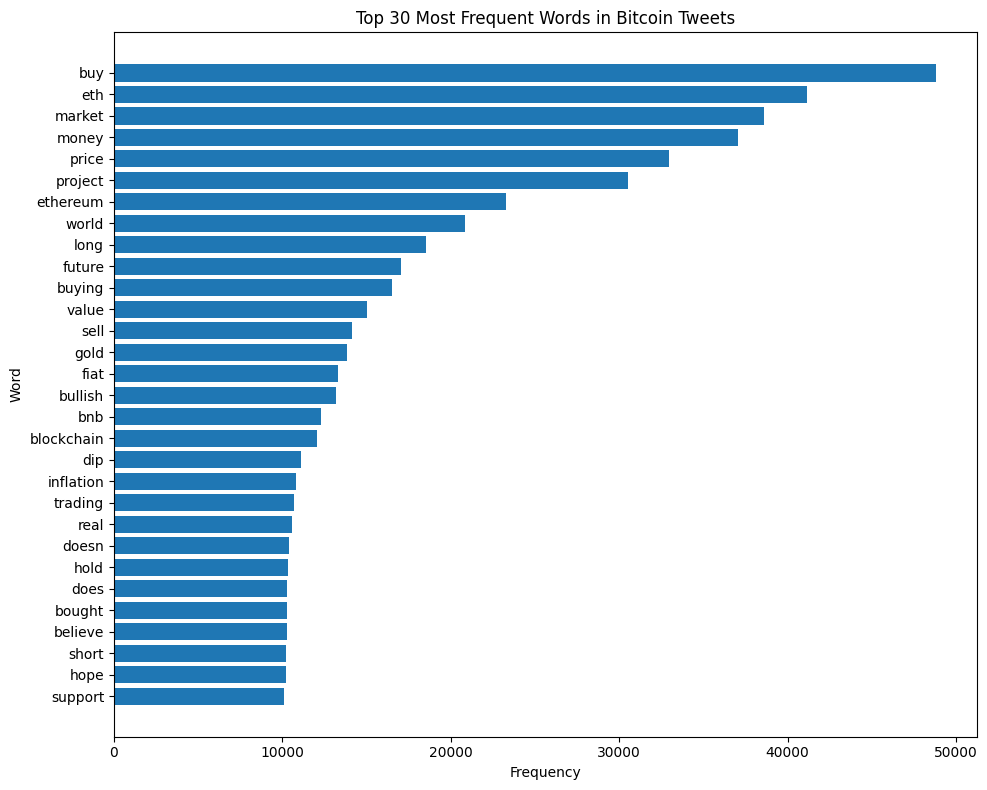

In [3]:
word_vectorizer_hd = CountVectorizer(
    stop_words=list(stopwords_hd),
    max_features=30
)

word_matrix_hd = word_vectorizer_hd.fit_transform(df_clean_hd["clean_text_hd"])

word_counts_hd = word_matrix_hd.sum(axis=0).A1
words_hd = word_vectorizer_hd.get_feature_names_out()

top_words_hd = (
    pd.DataFrame({
        "word": words_hd,
        "frequency": word_counts_hd
    })
    .sort_values(by="frequency", ascending=False)
    .reset_index(drop=True)
)

display(top_words_hd)

top_words_hd.to_csv(output_dir / "top_30_words.csv", index=False)

plt.figure(figsize=(10, 8))
plt.barh(top_words_hd["word"][::-1], top_words_hd["frequency"][::-1])
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Top 30 Most Frequent Words in Bitcoin Tweets")
plt.tight_layout()
plt.savefig(output_dir / "top_30_words.png", dpi=300, bbox_inches="tight")
plt.show()

,bigram,frequency
0,bear market,5601
1,long term,5432
2,bull run,2995
3,buy dip,2789
4,store value,2731
5,market cap,2705
6,short term,2636
7,bull market,2458
8,legal tender,1700
9,current price,1673


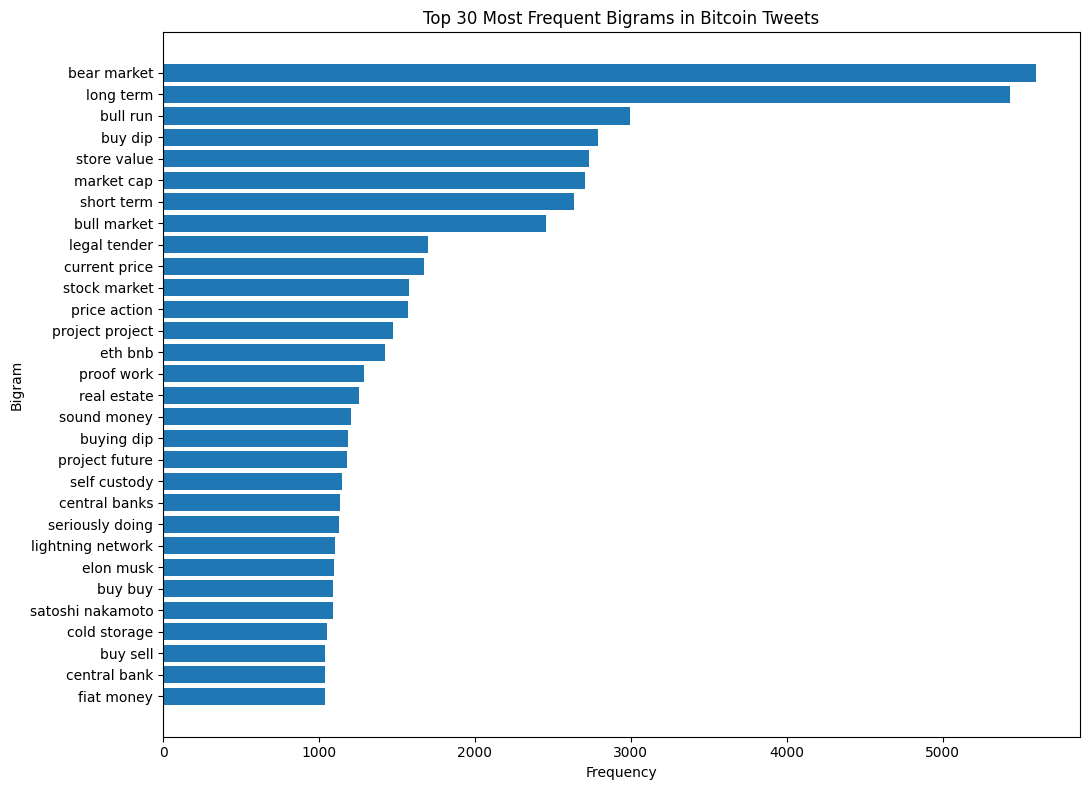

In [4]:
bigram_vectorizer_hd = CountVectorizer(
    stop_words=list(stopwords_hd),
    ngram_range=(2, 2),
    max_features=30
)

bigram_matrix_hd = bigram_vectorizer_hd.fit_transform(df_clean_hd["clean_text_hd"])

bigram_counts_hd = bigram_matrix_hd.sum(axis=0).A1
bigrams_hd = bigram_vectorizer_hd.get_feature_names_out()

top_bigrams_hd = (
    pd.DataFrame({
        "bigram": bigrams_hd,
        "frequency": bigram_counts_hd
    })
    .sort_values(by="frequency", ascending=False)
    .reset_index(drop=True)
)

display(top_bigrams_hd)

top_bigrams_hd.to_csv(output_dir / "top_30_bigrams.csv", index=False)

plt.figure(figsize=(11, 8))
plt.barh(top_bigrams_hd["bigram"][::-1], top_bigrams_hd["frequency"][::-1])
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.title("Top 30 Most Frequent Bigrams in Bitcoin Tweets")
plt.tight_layout()
plt.savefig(output_dir / "top_30_bigrams.png", dpi=300, bbox_inches="tight")
plt.show()